# 2. Data Inspection

Before we start doing anything with the data, we want to have a look at them! 
In this notebook we will inspect various aspects of the data. 

- Plot EEG data
- compute noise covariance
- compute data covariance


In [3]:
# imports
import os
import mne
import numpy as np

# data paths
subID = 24
data_path = "data"
subject_path = os.path.join(f"sub-0{subID}", "ses-mecha", "eeg")
epoch_file = f"sub-0{subID}_ses-mecha_task-NT_epo.fif"
epochs_path = os.path.join("..", data_path, subject_path, epoch_file)

### EEG Data
We load and inspect data from one participant.

In [4]:
# load data
epochs = mne.read_epochs(epochs_path, preload=True)


# inspect EEG data object
epochs

Reading /data/tu_grossmannr/Conferences/CuttingEEG2026/cuttingeeg-2026-sourcerec-tutorial/notebooks/../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_epo.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 62)  idle
    Found the data of interest:
        t =    -470.00 ...     430.00 ms
        0 CTF compensation matrices available
Adding metadata with 21 columns
893 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated


<EpochsFIF | 893 events (all good), -0.47 – 0.43 s (baseline -0.1 – 0 s), ~190.6 MiB, data loaded, with metadata,
 '15': 893>

### What is in the epochs object?

The epochs are cut around the onset of a near-threshold mechanical stimulus.
Every trial carries metadata, most importantly `response_decoded` (did the
participant report feeling the stimulus?) and `intensity_level`.

In [17]:
# basic properties of the recording
print(f"epochs      : {len(epochs)}")
print(f"channels    : {len(epochs.ch_names)} {set(epochs.get_channel_types())}")
print(f"sampling    : {epochs.info['sfreq']} Hz")
print(f"time window : {epochs.tmin:.3f} to {epochs.tmax:.3f} s (baseline {epochs.baseline})")
print(f"event ids   : {epochs.event_id}")
print(f"reference   : {[p['desc'] for p in epochs.info['projs']]}")

epochs      : 893
channels    : 62 {'eeg'}
sampling    : 500.0 Hz
time window : -0.470 to 0.430 s (baseline (-0.10000000149011612, 0.0))
event ids   : {'15': 15}
reference   : ['Average EEG reference']


In [18]:
# the metadata table: one row per trial
epochs.metadata.head()

,onset,total_secs,sub,modality,block,trialID,intensity_level,actual_intensity,response_decoded,trigger_missing,...,drop_epoch,force,force_zeromean,force_quantile,response_time,force_trigger_exists,intensity_norm,epoch_index,analysis_excluded,plot_excluded
0,1970-01-01 00:01:09.460000,69.460,24,Mechanical,1,0.0,4,2200,Yes,False,...,False,-2.893429,-10.946826,Low,0.229136,No,1.000000,0,False,False
1,1970-01-01 00:01:11.650200,71.650,24,Mechanical,1,1.0,2,2167,Yes,False,...,False,NaN,NaN,None,0.194694,No,0.985000,1,False,False
3,1970-01-01 00:01:14.941400,74.942,24,Mechanical,1,3.0,6,2234,Yes,False,...,False,2.169795,-5.883602,Low,0.186879,No,1.015455,3,False,True
4,1970-01-01 00:01:17.165000,77.164,24,Mechanical,1,4.0,2,2167,Yes,False,...,False,3.968636,-4.084761,Low,0.102376,No,0.985000,4,False,False
5,1970-01-01 00:01:19.220800,79.220,24,Mechanical,1,5.0,6,2234,Yes,False,...,False,2.002277,-6.051120,Low,0.206017,No,1.015455,5,False,True


In [19]:
# trials per condition
print(epochs.metadata["response_decoded"].value_counts(), "\n")

# trials per stimulus intensity and response -> the psychometric structure
print(epochs.metadata.groupby(["intensity_level", "response_decoded"]).size().unstack())

response_decoded
Yes    488
No     405
Name: count, dtype: int64 

response_decoded   No  Yes
intensity_level           
2                 107   72
3                  87   91
4                  75  104
5                  70  109
6                  66  112


In [20]:
# with metadata, trials are selected by writing pandas queries
perceived = epochs["response_decoded == 'Yes'"]
unperceived = epochs["response_decoded == 'No'"]
print(perceived)
print(unperceived)

<EpochsFIF | 488 events (all good), -0.47 – 0.43 s (baseline -0.1 – 0 s), ~104.2 MiB, data loaded, with metadata,
 '15': 488>
<EpochsFIF | 405 events (all good), -0.47 – 0.43 s (baseline -0.1 – 0 s), ~86.5 MiB, data loaded, with metadata,
 '15': 405>


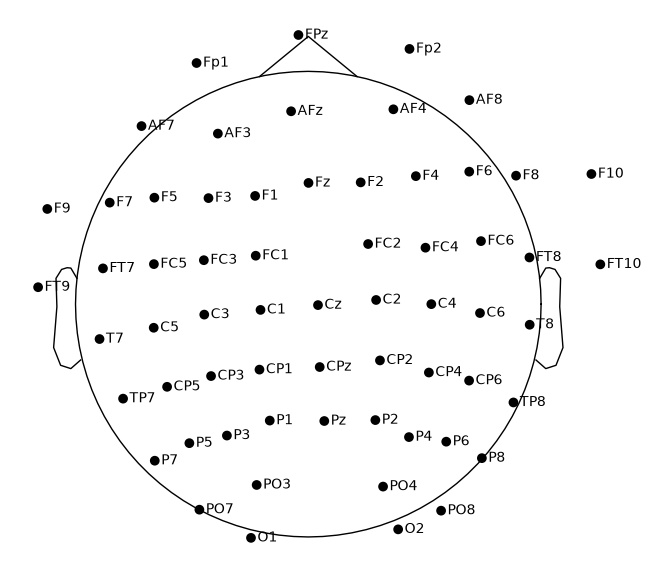

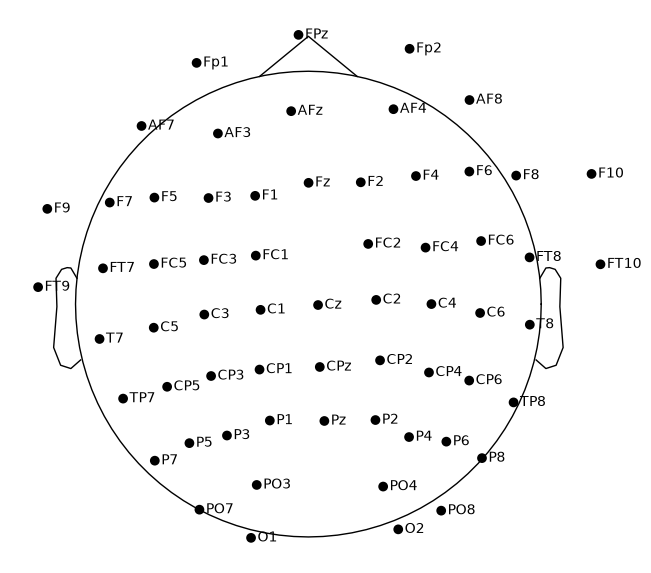

In [21]:
# sensor layout - this montage defines the forward model later on
epochs.plot_sensors(show_names=True, sphere="auto")

### Spectrum

Sanity check for line noise, drifts and bad channels: power spectrum per
channel and the topography of the classical frequency bands.

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/data/u_grossmannr_software/miniforge3/envs/sourcerec-tutorial/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


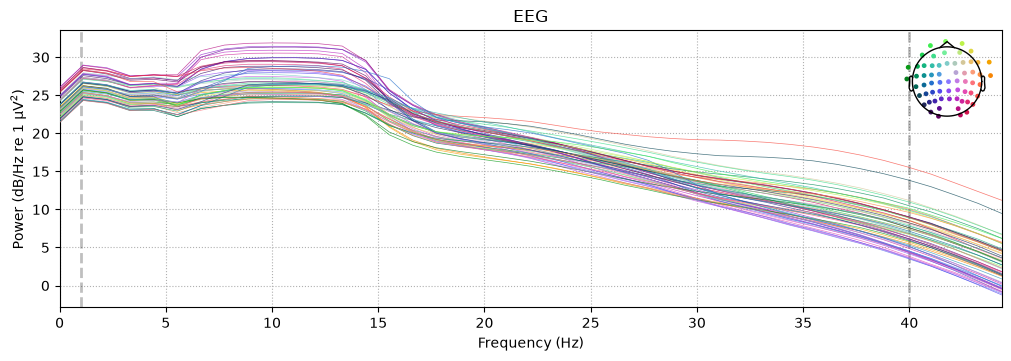

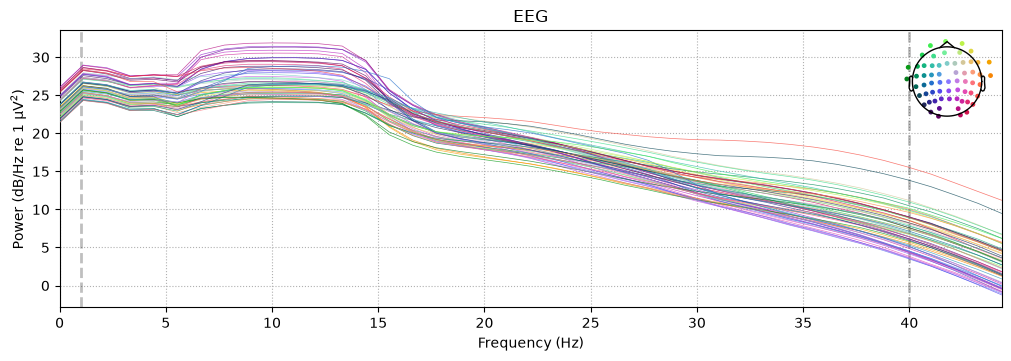

In [23]:
spectrum = epochs.compute_psd(fmax=45)

# one line per channel - outliers are candidates for bad channels
spectrum.plot(picks="eeg", amplitude=False, spatial_colors=True)

Averaging across epochs before plotting...


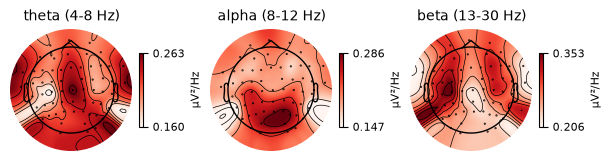

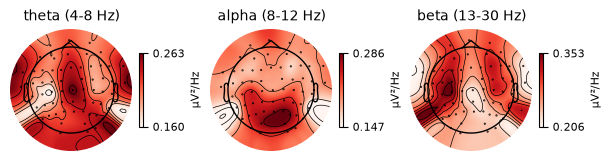

In [24]:
# where is the power of each band on the scalp?
spectrum.plot_topomap(
    bands={"theta (4-8 Hz)": (4, 8), "alpha (8-12 Hz)": (8, 12), "beta (13-30 Hz)": (13, 30)},
    normalize=True,
)

### Single trials

`plot_image` shows every trial as one row of a colour-coded image, with the
average underneath. Sorting the rows by metadata makes condition differences
visible in the single-trial data.

Not setting metadata
893 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


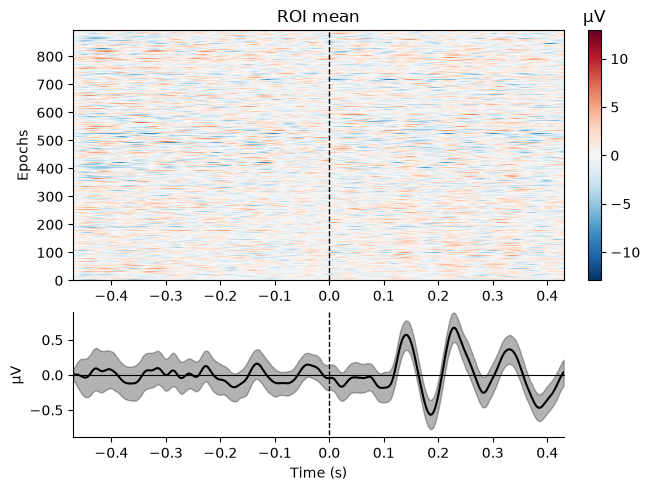

[<Figure size 640x480 with 3 Axes>]

In [27]:
roi = ["CP4", "C4", "C6"]

epochs.plot_image(picks=roi, combine="mean", sigma=1.0, title="ROI mean")

Not setting metadata
893 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


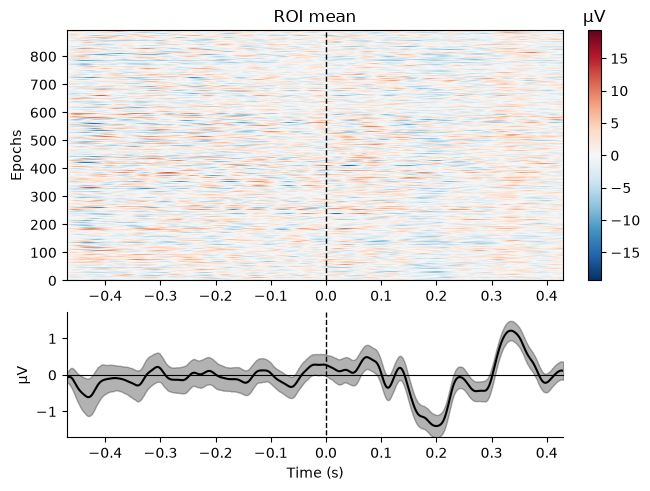

[<Figure size 640x480 with 3 Axes>]

In [29]:
# centro-parietal ROI: where the detection effect is largest in this participant
roi = ["O1", "O2"]

epochs.plot_image(picks=roi, combine="mean", sigma=1.0, title="ROI mean")

Not setting metadata
893 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


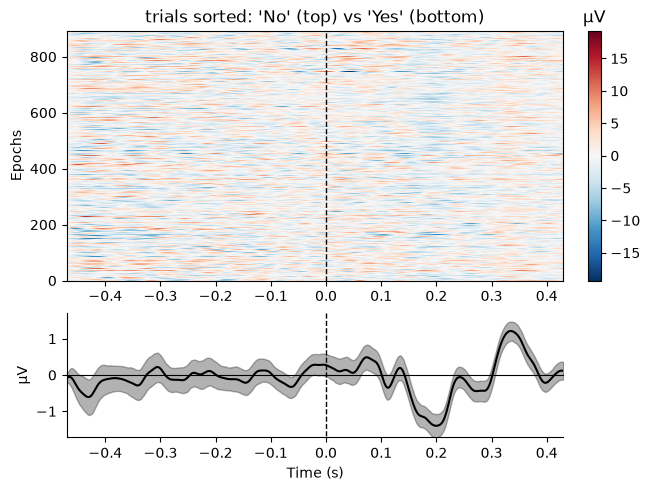

[<Figure size 640x480 with 3 Axes>]

In [30]:
# same image, trials sorted so that the two responses form two blocks
order = np.argsort(epochs.metadata["response_decoded"].values)

epochs.plot_image(picks=roi, combine="mean", order=order, sigma=1.0,
                  title="trials sorted: 'No' (top) vs 'Yes' (bottom)")

### Evoked response

Averaging over trials gives the somatosensory evoked potential. `plot_joint`
combines the butterfly plot with topographies at the peaks.

Projections have already been applied. Setting proj attribute to True.


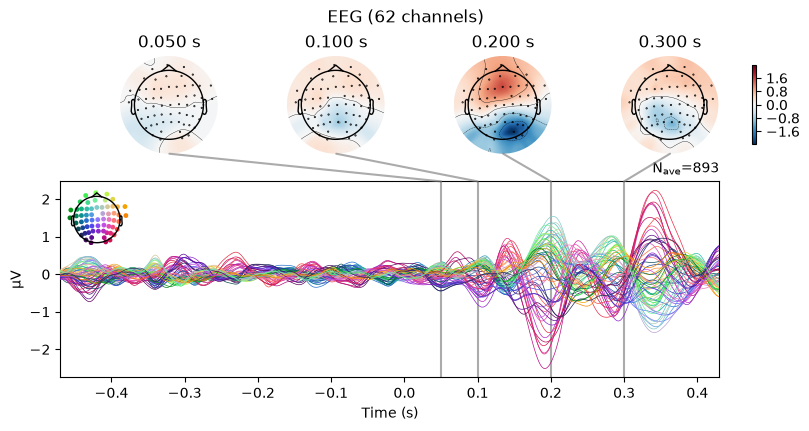

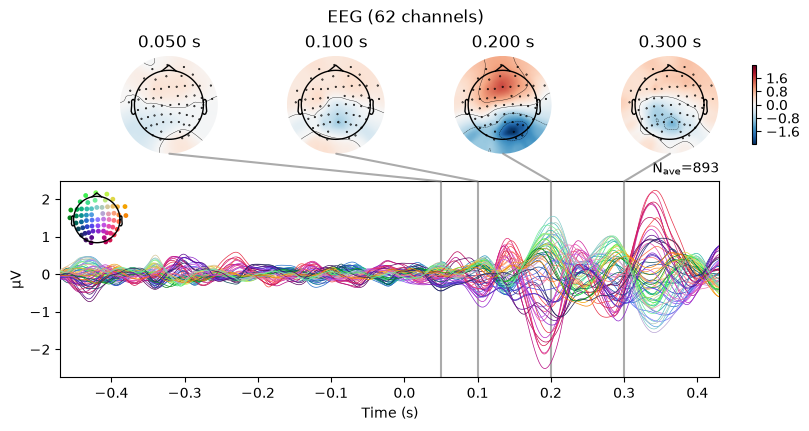

In [31]:
evoked = epochs.average()
evoked.plot_joint(times=[0.05, 0.1, 0.2, 0.3])

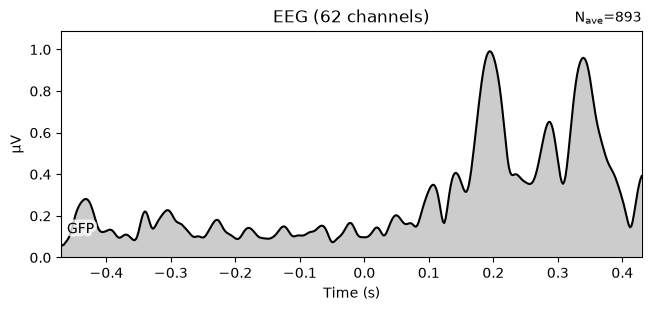

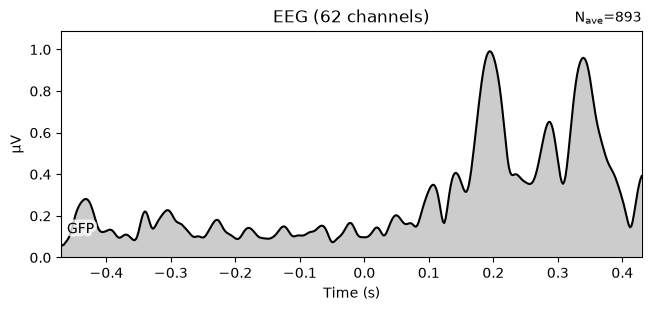

In [32]:
# global field power: when does the evoked response carry the most signal?
evoked.plot(gfp="only", spatial_colors=True)

### Perceived vs. unperceived

The contrast that the source reconstruction is applied to later.

ROIs ['O1', 'O2']
combining channels using "mean"
combining channels using "mean"


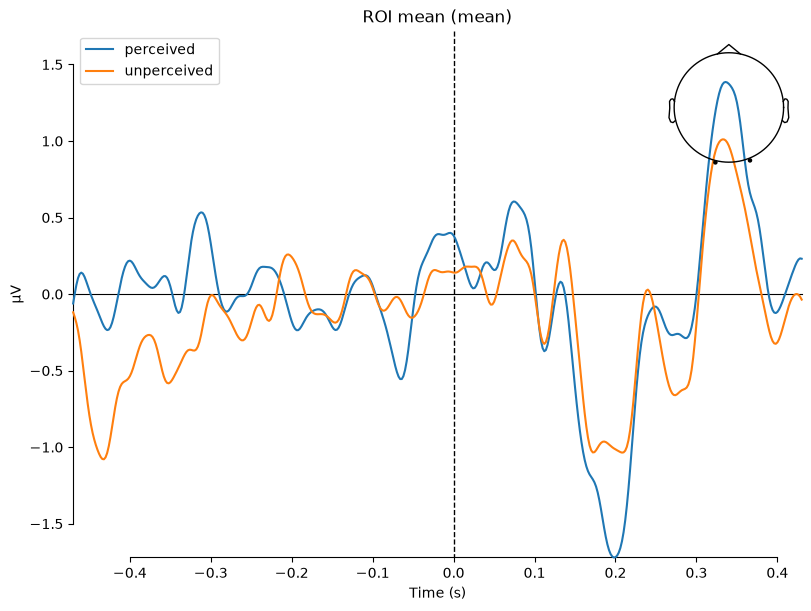

[<Figure size 800x600 with 2 Axes>]

In [34]:
evokeds = {"perceived": perceived.average(), "unperceived": unperceived.average()}
print("ROIs", roi)
mne.viz.plot_compare_evokeds(evokeds, picks=roi, combine="mean",
                             show_sensors="upper right", title="ROI mean")

combining channels using "mean"
combining channels using "mean"


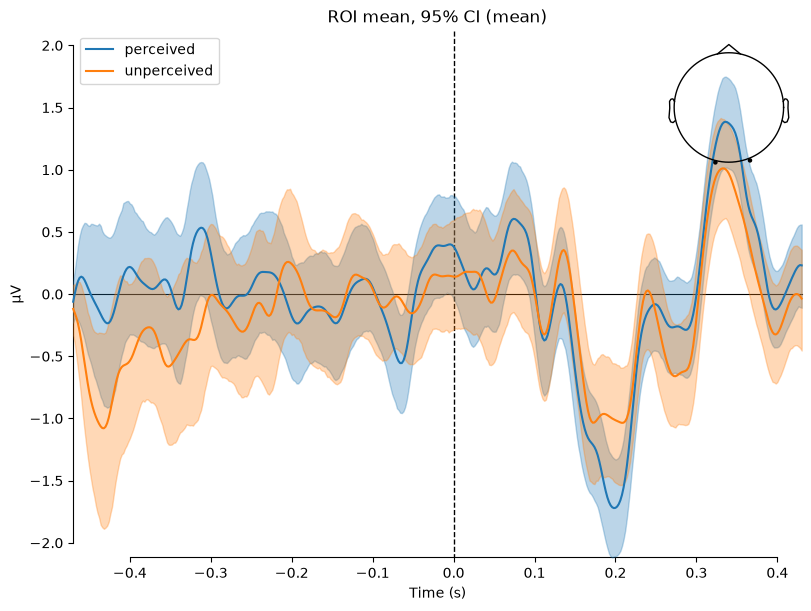

[<Figure size 800x600 with 2 Axes>]

In [35]:
# with confidence intervals: pass the single-trial evokeds instead of the averages
evokeds_trials = {"perceived": list(perceived.iter_evoked()),
                  "unperceived": list(unperceived.iter_evoked())}

mne.viz.plot_compare_evokeds(evokeds_trials, picks=roi, combine="mean", ci=0.95,
                             show_sensors="upper right", title="ROI mean, 95% CI")

Projections have already been applied. Setting proj attribute to True.


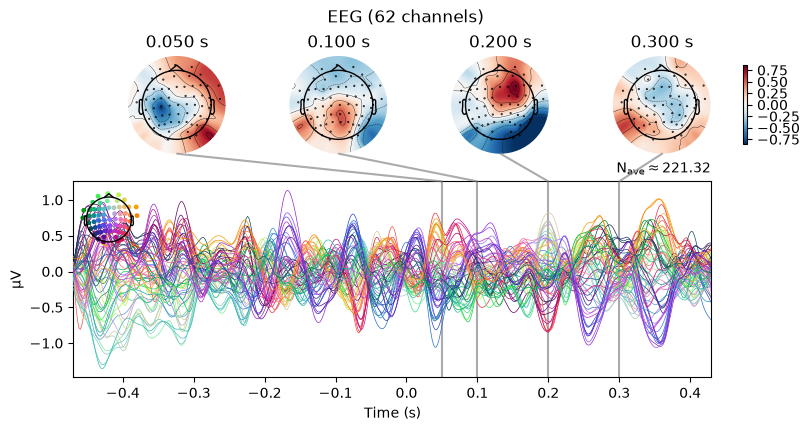

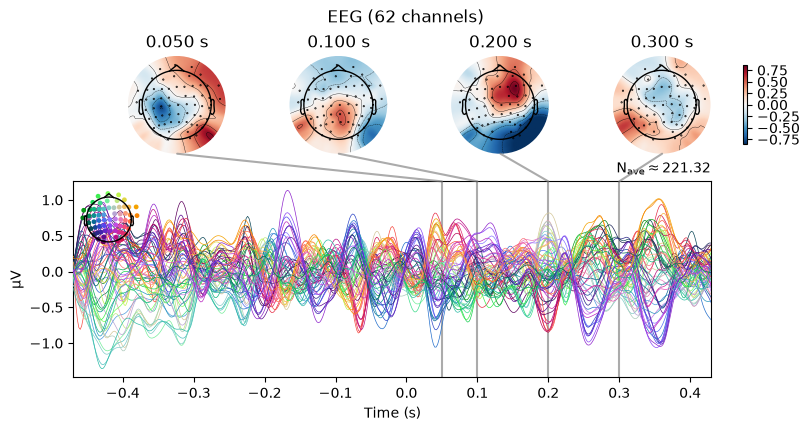

In [36]:
# difference wave
difference = mne.combine_evoked([evokeds["perceived"], evokeds["unperceived"]],
                                weights=[1, -1])
difference.comment = "perceived - unperceived"
difference.plot_joint(times=[0.05, 0.1, 0.2, 0.3])

### Topographies

How the scalp distribution evolves over time - these are the patterns the
inverse solution has to explain.

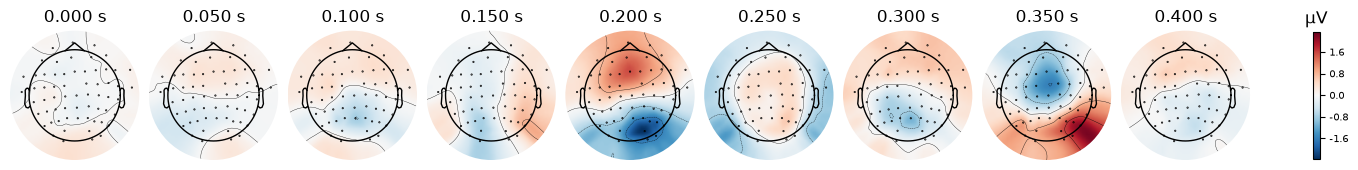

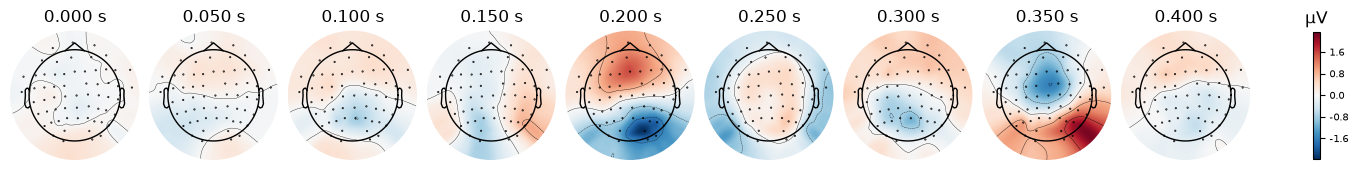

In [37]:
evoked.plot_topomap(times=np.arange(0.0, 0.41, 0.05), ch_type="eeg", colorbar=True)

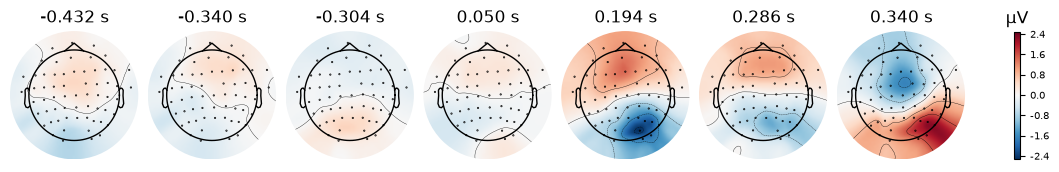

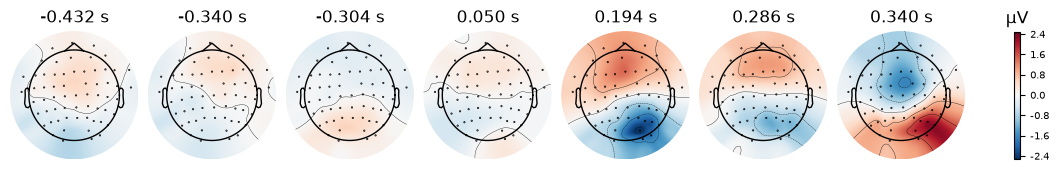

In [38]:
# topographies at the peaks of the global field power
evoked.plot_topomap(times="peaks", ch_type="eeg", colorbar=True)

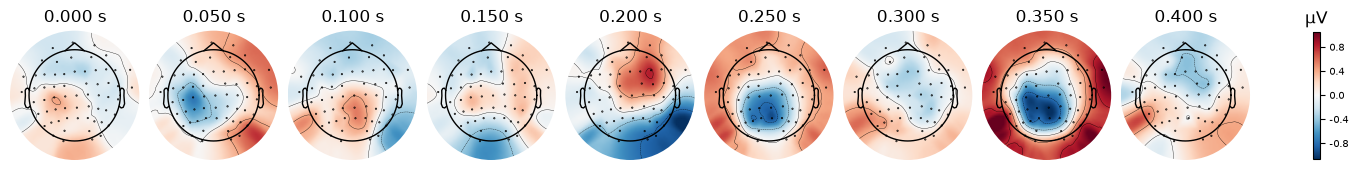

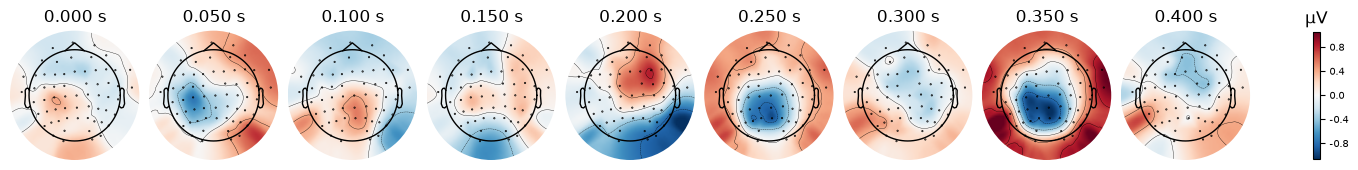

In [39]:
difference.plot_topomap(times=np.arange(0.0, 0.41, 0.05), ch_type="eeg", colorbar=True)